### IMPORTS


In [13]:
import sys, os
sys.path.append(os.path.abspath("src"))
from google.colab import files
uploaded = files.upload()
from gaussian_model import GaussianGenerativeModel
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from numpy.linalg import slogdet, inv
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from gaussian_model import GaussianGenerativeModel


Saving gaussian_model.py to gaussian_model (1).py


### 1. Load the dataset


In [14]:
digits = load_digits()
X = digits.data
y = digits.target


### 2. Create 70% / 15% / 15% split
###   using stratified splitting


In [15]:
# bngeeb First split_Training (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# bngeeb Second split_Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

### 3. Standardize the features
###    using only training statistics

In [16]:
scaler = StandardScaler()
# bn3mel scale 34an yshta8al asra3 w more accurately for all features 34an lw msh scaled -> gradient descent becomes slow w unstable
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_val_std   = scaler.transform(X_val)
X_test_std  = scaler.transform(X_test)

# Check shapes
print("Training set:", X_train_std.shape)
print("Validation set:", X_val_std.shape)
print("Test set:", X_test_std.shape)

Training set: (1257, 64)
Validation set: (270, 64)
Test set: (270, 64)


## Train the Model

In [17]:
lambda_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
# bn train el lambda with difference values 34an t classify
best_lambda = None
best_val_acc = -1

for lam in lambda_values:
    model = GaussianGenerativeModel(lambda_reg=lam)
    model.fit(X_train_std, y_train)
    val_acc = model.accuracy(X_val_std, y_val)

    print(f"λ = {lam:.0e}, Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lambda = lam
# bn print ahsn lambda w el accuracy
print("\nBest λ:", best_lambda)
print("Best validation accuracy:", best_val_acc)


λ = 1e-06, Validation Accuracy = 0.9444
λ = 1e-05, Validation Accuracy = 0.9444
λ = 1e-04, Validation Accuracy = 0.9444
λ = 1e-03, Validation Accuracy = 0.9444
λ = 1e-02, Validation Accuracy = 0.9444
λ = 1e-01, Validation Accuracy = 0.9444

Best λ: 1e-06
Best validation accuracy: 0.9444444444444444


## Train Final Model Using Best λ

In [18]:
final_model = GaussianGenerativeModel(lambda_reg=best_lambda)
final_model.fit(X_train_std, y_train)

test_acc = final_model.accuracy(X_test_std, y_test)

print("Final Test Accuracy:", test_acc)


Final Test Accuracy: 0.9592592592592593


### λ values and evaluate on validation set

In [19]:
# bn3mel validation to get best accuracy

lambda_candidates = [1e-4, 1e-3, 1e-2, 1e-1]

val_results = []

for lam in lambda_candidates:
    model = GaussianGenerativeModel(lambda_reg=lam)
    model.fit(X_train_std, y_train)

    val_acc = model.accuracy(X_val_std, y_val)
    val_results.append((lam, val_acc))

    print(f"λ = {lam:.0e} → Validation Accuracy = {val_acc:.4f}")

# Select the best λ
best_lambda, best_val_acc = max(val_results, key=lambda x: x[1])

print("\nBest λ:", best_lambda)
print("Best Validation Accuracy:", best_val_acc)


λ = 1e-04 → Validation Accuracy = 0.9444
λ = 1e-03 → Validation Accuracy = 0.9444
λ = 1e-02 → Validation Accuracy = 0.9444
λ = 1e-01 → Validation Accuracy = 0.9444

Best λ: 0.0001
Best Validation Accuracy: 0.9444444444444444


### Combine Training + Validation and Retrain Final Model

In [20]:
# Combine training & validation
X_train_full = np.vstack([X_train_std, X_val_std])
y_train_full = np.concatenate([y_train, y_val])

# Train with best lambda
final_model = GaussianGenerativeModel(lambda_reg=best_lambda)
final_model.fit(X_train_full, y_train_full)

# Evaluate on the test set ll newpoints
y_pred_test = final_model.predict(X_test_std)
test_acc = np.mean(y_pred_test == y_test)

print("Final Test Accuracy:", test_acc)


Final Test Accuracy: 0.9629629629629629


### Compute Precision, Recall, F1 (Macro-Averaged)

In [22]:
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_test, average='macro'
)

print("Macro Precision:", prec)
print("Macro Recall:", rec)
print("Macro F1-score:", f1)


Macro Precision: 0.9631904761904762
Macro Recall: 0.9626577126577127
Macro F1-score: 0.9624803472389681


### Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred_test)
cm


array([[27,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 26,  0,  0,  0,  0,  0,  0,  1,  1],
       [ 0,  0, 26,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 28,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 27,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 27,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 27,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 27,  0,  0],
       [ 0,  3,  0,  0,  0,  0,  0,  0, 22,  1],
       [ 0,  1,  0,  0,  0,  1,  0,  1,  1, 23]])

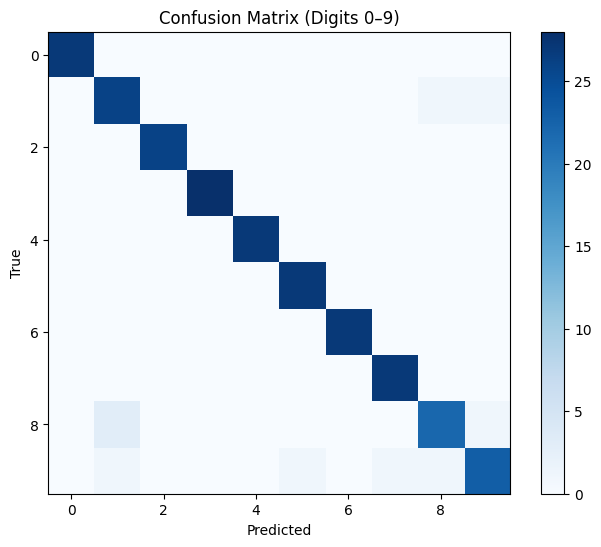

In [24]:
# lastly hena n print el matrix graphically :)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Digits 0–9)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()
